In [1]:
import os
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

In [2]:
data_dir = "/kaggle/input/datasets/adammilingu/conser-vision-classification"

# List everything directly inside your dataset folder
print("--- Root Contents ---")
for item in os.listdir(data_dir):
    print(item)

--- Root Contents ---
benchmark.ipynb
train_features
train_labels.csv
train_features.csv
test_features.csv
submission_format.csv
test_features


In [3]:
# Load the CSV Labels and Inspect
labels_df = pd.read_csv(os.path.join(data_dir, "train_labels.csv"))

print("\n--- Train Labels Head ---")
print(labels_df.head())

print("\n--- Columns in Dataset ---")
print(labels_df.columns)



--- Train Labels Head ---
         id  antelope_duiker  bird  blank  civet_genet  hog  leopard  \
0  ZJ000000              0.0   1.0    0.0          0.0  0.0      0.0   
1  ZJ000001              0.0   0.0    0.0          0.0  0.0      0.0   
2  ZJ000002              0.0   1.0    0.0          0.0  0.0      0.0   
3  ZJ000003              0.0   0.0    0.0          0.0  0.0      0.0   
4  ZJ000004              0.0   0.0    0.0          0.0  0.0      1.0   

   monkey_prosimian  rodent  
0               0.0     0.0  
1               1.0     0.0  
2               0.0     0.0  
3               1.0     0.0  
4               0.0     0.0  

--- Columns in Dataset ---
Index(['id', 'antelope_duiker', 'bird', 'blank', 'civet_genet', 'hog',
       'leopard', 'monkey_prosimian', 'rodent'],
      dtype='object')


In [4]:
# 1. Pick the first row in your DataFrame
sample_row = labels_df.iloc[0]
sample_row

id                  ZJ000000
antelope_duiker          0.0
bird                     1.0
blank                    0.0
civet_genet              0.0
hog                      0.0
leopard                  0.0
monkey_prosimian         0.0
rodent                   0.0
Name: 0, dtype: object

In [5]:
# 2. Extract the image ID/name from your column
image_filename = sample_row["id"]
image_filename

'ZJ000000'

Opening sample image from path: /kaggle/input/datasets/adammilingu/conser-vision-classification/train_features/ZJ000000.jpg
Image Resolution: (960, 540) | Mode: RGB


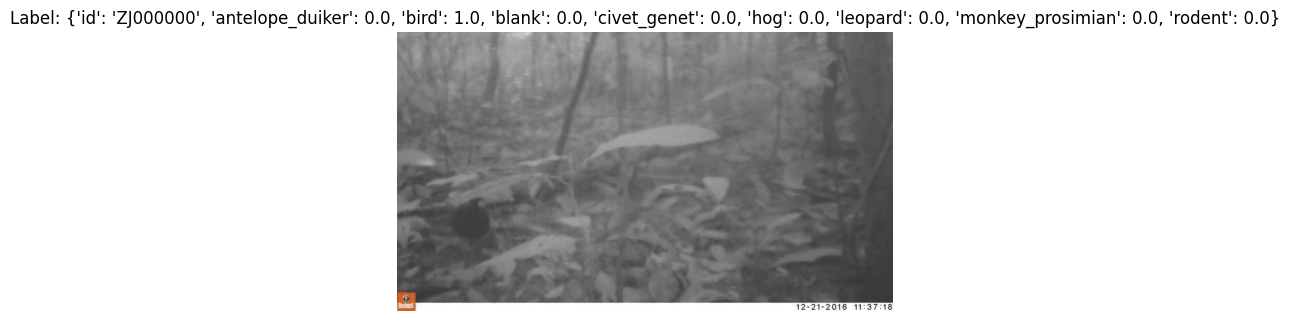

In [6]:
# Map Labels to Image Paths and Open a Single Image

if not image_filename.endswith('.jpg'): image_filename += '.jpg'

# 3. Construct the absolute file path to the image
train_features_dir = os.path.join(data_dir, "train_features")
img_path = os.path.join(train_features_dir, image_filename)

print(f"Opening sample image from path: {img_path}")

# 4. Open and display the single image
try:
    img = Image.open(img_path)
    print(f"Image Resolution: {img.size} | Mode: {img.mode}")
    
    # Plot it
    plt.imshow(img)
    plt.title(f"Label: {sample_row.to_dict()}") # Displays all columns for context
    plt.axis("off")
    plt.show()
except FileNotFoundError:
    print(f"Error: Could not find image at {img_path}. Check if your folder name is 'train_features' or if the extension is missing.")
